In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
# 1. 读取数据
df = pd.read_csv('../data/tradeoffdata.csv')

In [2]:
df.head()

,LLM,Dataset,Setting,ASR,ULR,ARE,CLF,SS,answer_relevancy,answer_infodepth,faithfulness
0,Qwen3-32B,FiQA,vanilla,113,258,865,0.8391,0.7546,0.8058,0.8045,0.7708
1,Qwen3-32B,FiQA,rrk,109,204,840,0.8907,0.7401,0.8019,0.8045,0.7490
2,Qwen3-32B,FiQA,rrk+rwt,100,188,891,0.8488,0.7456,0.8353,0.8047,0.7588
3,Qwen3-32B,FiQA,rrk+rwt+sum,56,88,894,0.5860,0.7244,0.8218,0.7922,0.6107
4,o4-mini,FiQA,vanilla,38,83,865,0.8505,0.6452,0.7784,0.7763,0.6895


In [3]:
df["ASR"] = df["ASR"] /200
df["ULR"] = df["ULR"] /1000
df["ARE"] = df["ARE"] /1000

In [4]:
# 数据集名称列表
datasets = ['FiQA', 'NFcorpus', 'SciFact']
LLMs =['DeepSeek-V3', 'Gemma-3-IT-27B', 'Kimi-K2-0711', 'Qwen2.5-14B-Instruct', 'Qwen3-32B', 'o4-mini']
metrics = ['ASR', 'ULR', 'ARE', 'CLF', 'SS', 'answer_relevancy', 'answer_infodepth', 'faithfulness']

df_split_by_datasets = [df[df['Dataset'] == dataset] for dataset in datasets]

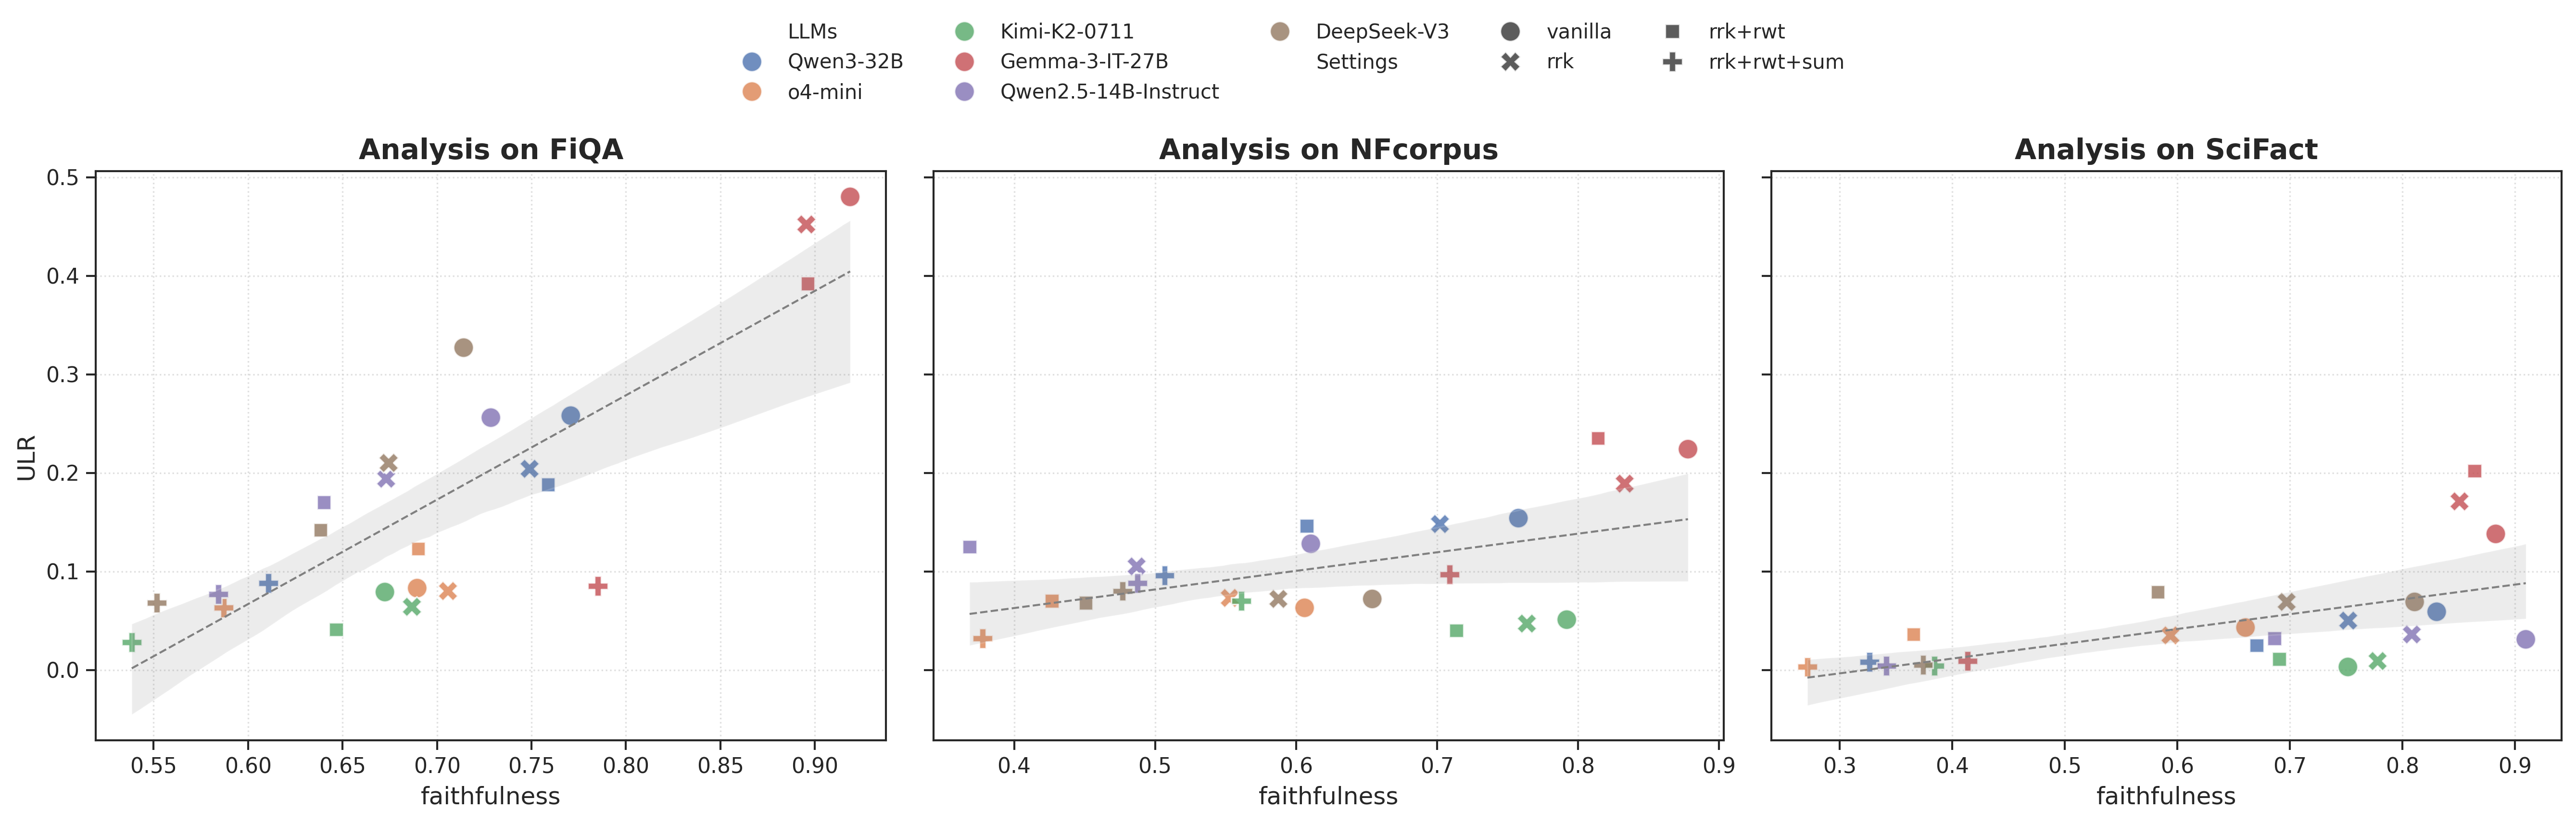

In [5]:
# 2. 设置科研画风
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman']
# plt.rcParams['axes.unicode_minus'] = False
sns.set_context("paper", font_scale=1.2)
sns.set_style("ticks")

# 3. 创建画布：1行3列
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)


for i, ax in enumerate(axes):
    # --- 这里替换为你真实的数据抽取逻辑 ---
    # 模拟一份数据
    data = pd.DataFrame({
        'faithfulness': df_split_by_datasets[i]["faithfulness"],
        'answer_relevancy': df_split_by_datasets[i]["answer_relevancy"],
        'info_depth': df_split_by_datasets[i]["answer_infodepth"],
        'ASR':  df_split_by_datasets[i]["ASR"],
        'ULR':  df_split_by_datasets[i]["ULR"],
        'ARE':  df_split_by_datasets[i]["ARE"],
        'CLF':  df_split_by_datasets[i]["CLF"],
        'SS':   df_split_by_datasets[i]["SS"],
        'LLMs': df_split_by_datasets[i]["LLM"],
        'Settings': df_split_by_datasets[i]["Setting"]
    })
    
    # 绘制散点图
    # hue: 区分模型颜色, style: 区分策略形状
    sns.scatterplot(data=data, x='faithfulness', y='ULR', 
                    hue='LLMs', style='Settings', 
                    s=100, ax=ax, palette='deep', alpha=0.8, edgecolor='w')
    
    # 绘制线性回归趋势线 (反映正负相关性)
    sns.regplot(data=data, x='faithfulness', y='ULR', 
                scatter=False, ax=ax, color='gray', line_kws={"ls":"--", "lw":1})

    # 子图细节优化
    ax.set_title(f'Analysis on {datasets[i]}', fontsize=14, fontweight='bold')
    ax.set_xlabel('faithfulness', fontsize=12)
    if i == 0:
        ax.set_ylabel('ULR', fontsize=12)
    
    ax.grid(True, linestyle=':', alpha=0.6)

# 4. 合并图例
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), 
           ncol=5, frameon=False, fontsize=10)

# 移除原始子图内部图例
for ax in axes:
    ax.get_legend().remove()

plt.tight_layout()
# plt.savefig('scatter_comparison.pdf', bbox_inches='tight')
plt.show()

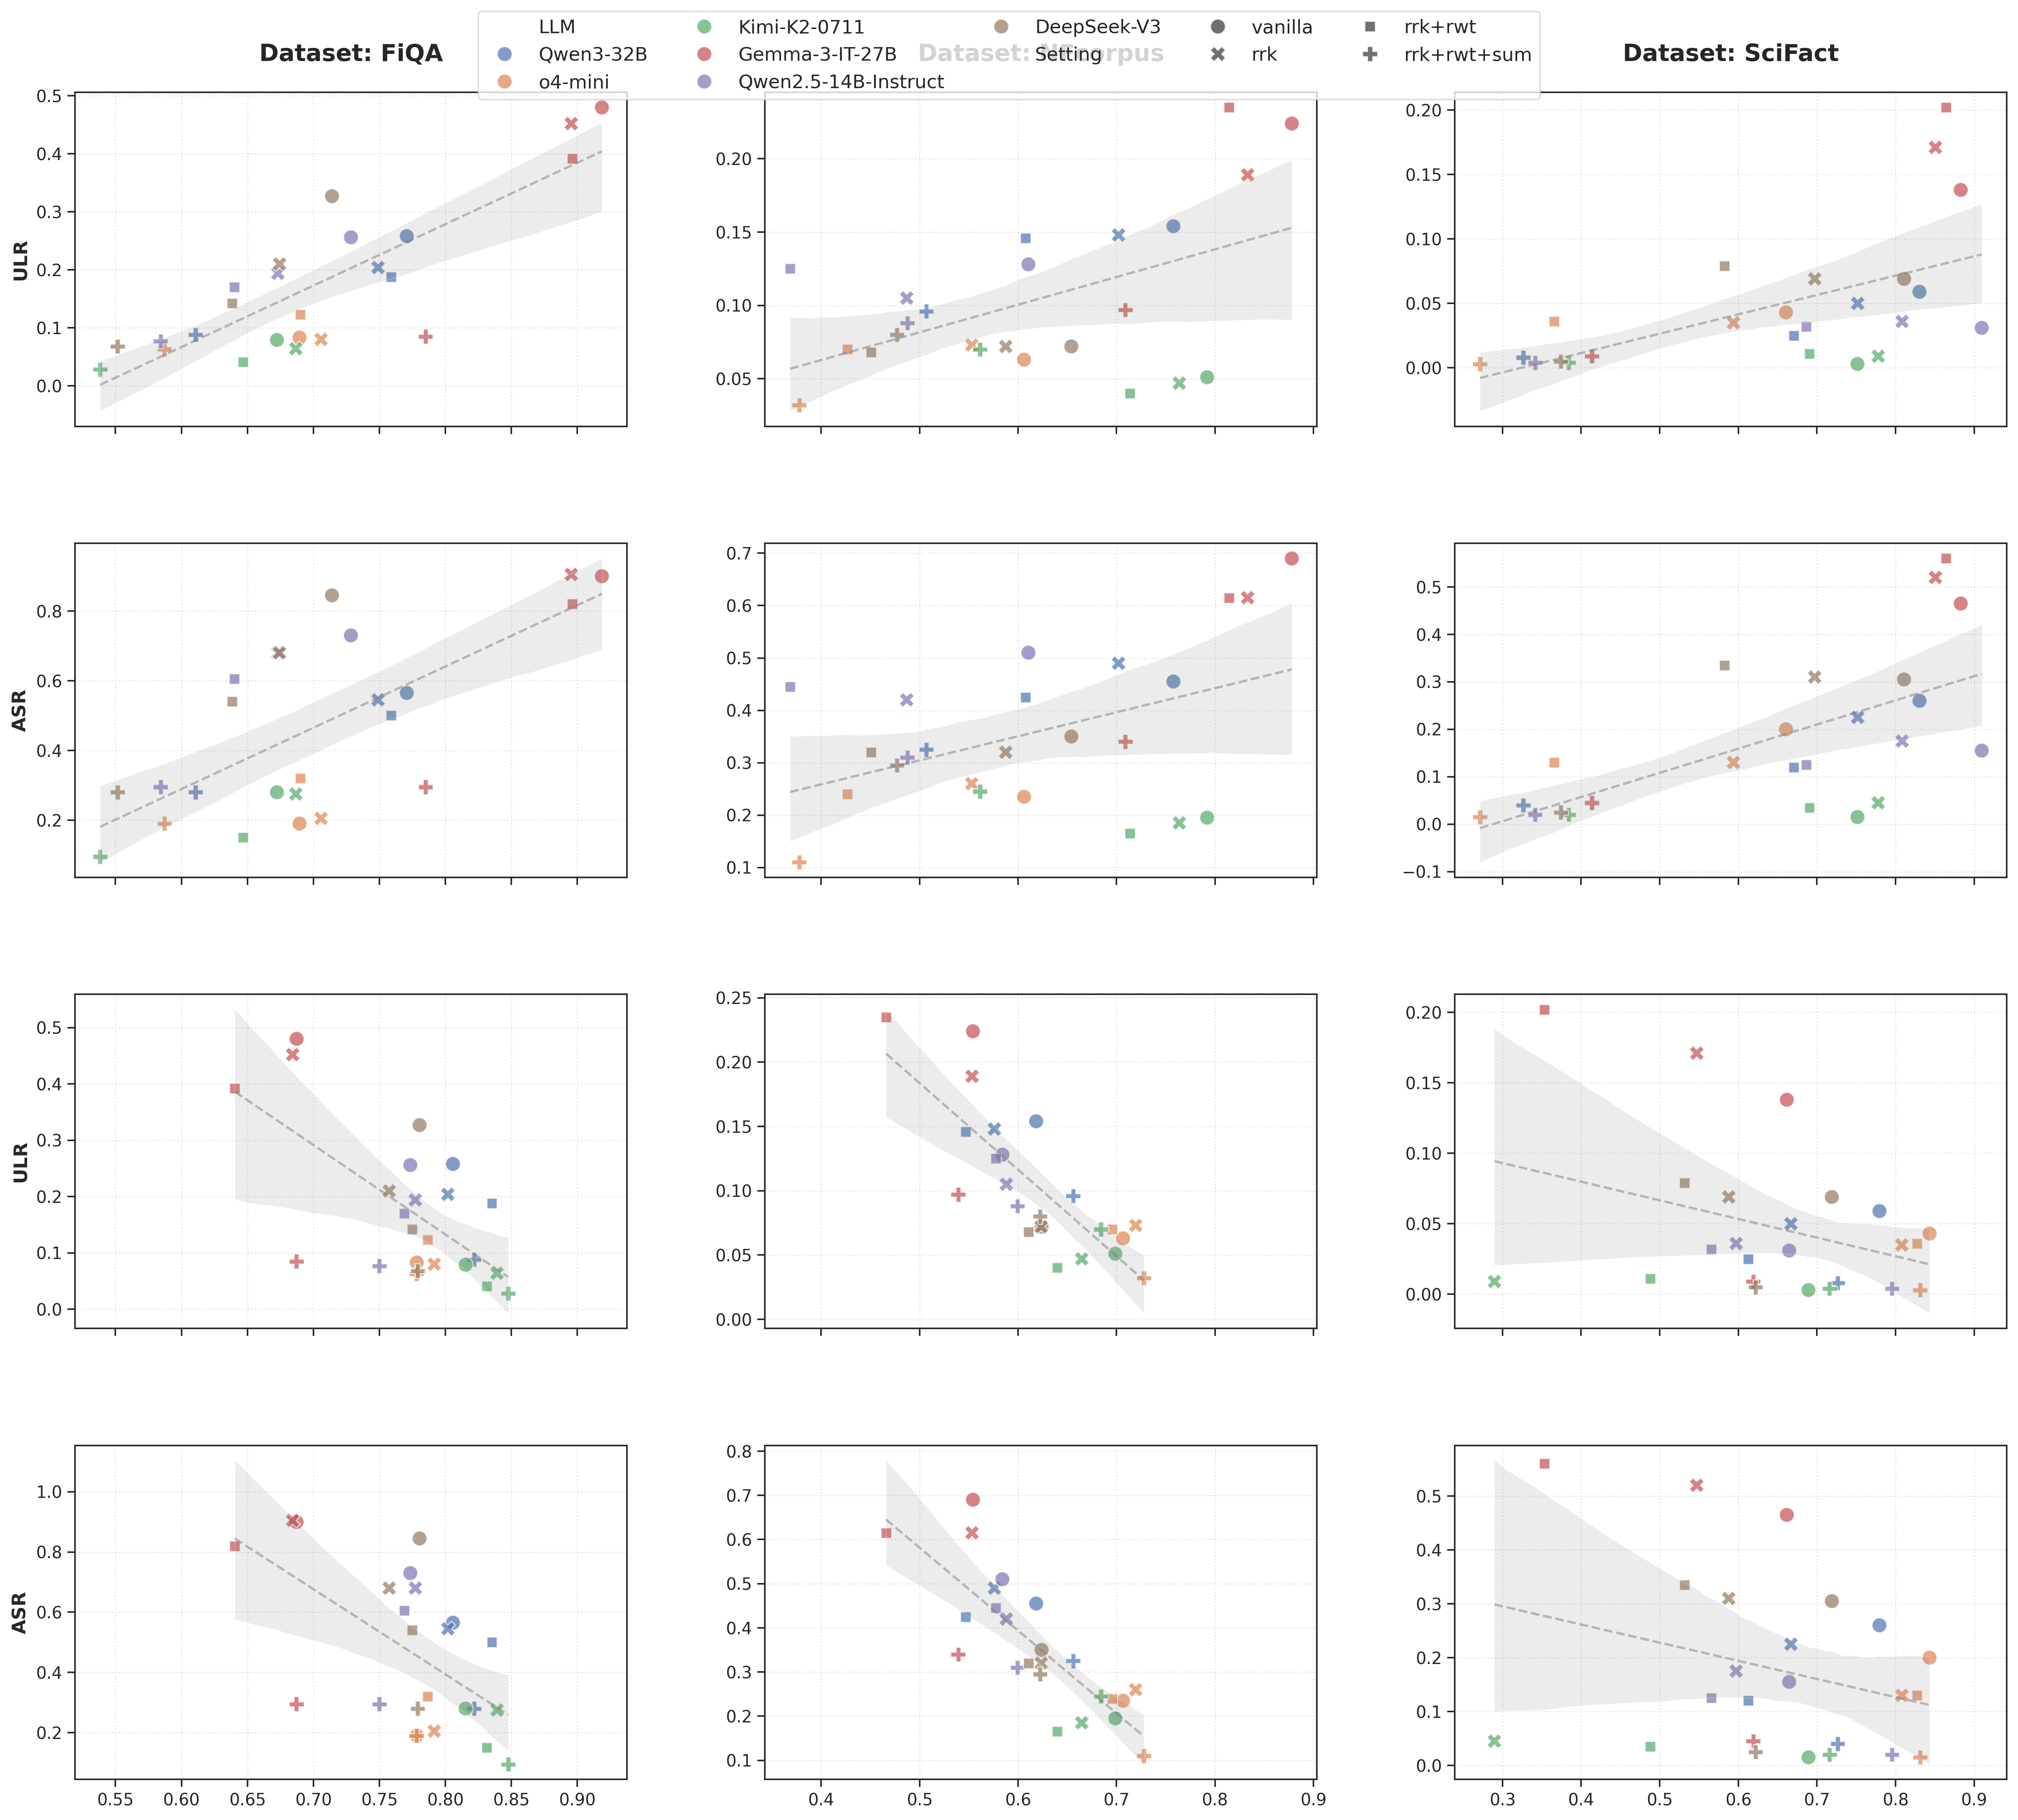

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 预定义指标组合 (6组对比)
pairs = [
    ('faithfulness', 'ULR'), ('faithfulness', 'ASR'), 
    ('answer_relevancy', 'ULR'), ('answer_relevancy', 'ASR')
]

# 2. 样式设置
# 提示：如果环境支持，建议取消 Times New Roman 的注释以符合 ACL 要求
sns.set_context("paper", font_scale=1.2)
sns.set_style("ticks")

# 3. 创建 6x3 画布
# 【关键修改】：去掉了 sharey=True。
# sharex='col' 建议保留，因为同一列的横轴指标相同，对齐可以方便对比。
fig, axes = plt.subplots(4, 3, figsize=(18, 16), 
                         sharex='col', sharey=False, 
                         dpi=300)

for row_idx, (x_col, y_col) in enumerate(pairs):
    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        
        # 获取当前数据集的数据
        df_curr = df_split_by_datasets[col_idx]
        
        # 绘图
        sns.scatterplot(data=df_curr, x=x_col, y=y_col, 
                        hue='LLM', style='Setting', 
                        s=90, ax=ax, palette='deep', alpha=0.7, edgecolor='w')
        
        # 绘制回归线
        sns.regplot(data=df_curr, x=x_col, y=y_col, 
                    scatter=False, ax=ax, color='gray', 
                    line_kws={"ls":"--", "lw":1.5, "alpha":0.5})

        # --- 细节美化 ---
        
        # 设置标题：只在每一列的最上方
        if row_idx == 0:
            ax.set_title(f'Dataset: {datasets[col_idx]}', fontsize=15, fontweight='bold', pad=20)
        
        # 设置 X 轴标签：只在每一列的最下方（为了保持整洁）
        if row_idx == 5:
            ax.set_xlabel(x_col, fontsize=12, fontweight='bold')
        else:
            ax.set_xlabel('')

        # 设置 Y 轴标签：既然不共享纵轴，每一张子图最好都带上标签，或者每行第一张带上
        # 这里建议每行第一张显示大标签，其余显示小标签或不显示，以防拥挤
        if col_idx == 0:
            ax.set_ylabel(y_col, fontsize=12, fontweight='bold')
        else:
            # ax.set_ylabel(y_col, fontsize=10) 
            ax.set_ylabel('')

        ax.grid(True, linestyle=':', alpha=0.5)
        
        # 实时移除子图图例
        if ax.get_legend() is not None:
            ax.get_legend().remove()

# 4. 强制对齐所有标签位置 (解决你提到的对齐问题)
fig.align_labels() 

# 5. 全局图例：放在画布顶部
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.01), 
           ncol=5, frameon=True, fontsize=12)

# 6. 调整间距
# 因为不共享纵轴，每个图都有独立的刻度，适当增加 wspace (宽度间距)
plt.tight_layout()
plt.subplots_adjust(top=0.96, hspace=0.35, wspace=0.25)

plt.show()

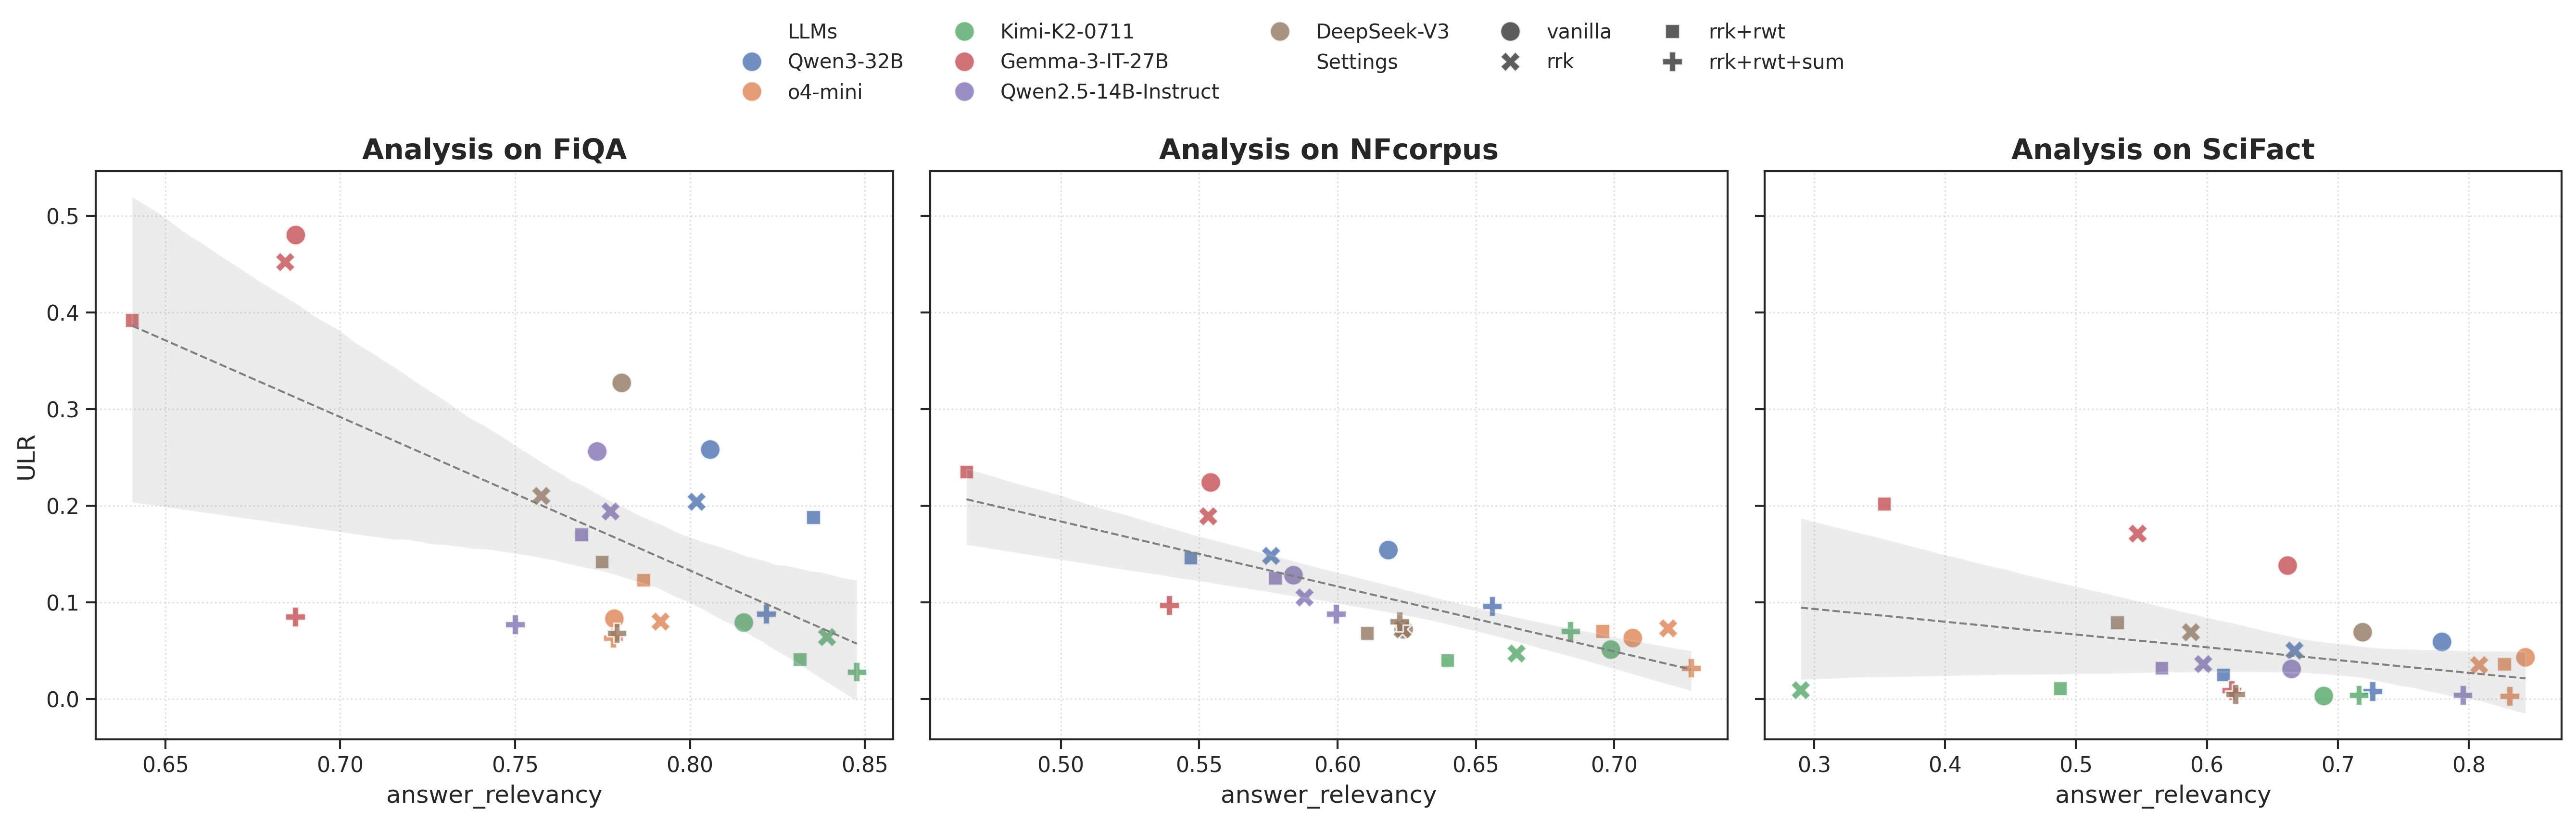

In [7]:
sns.set_context("paper", font_scale=1.2)
sns.set_style("ticks")

# 3. 创建画布：1行3列
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)


for i, ax in enumerate(axes):
    # --- 这里替换为你真实的数据抽取逻辑 ---
    # 模拟一份数据
    data = pd.DataFrame({
        'faithfulness': df_split_by_datasets[i]["faithfulness"],
        'answer_relevancy': df_split_by_datasets[i]["answer_relevancy"],
        'info_depth': df_split_by_datasets[i]["answer_infodepth"],
        'ASR':  df_split_by_datasets[i]["ASR"],
        'ULR':  df_split_by_datasets[i]["ULR"],
        'ARE':  df_split_by_datasets[i]["ARE"],
        'CLF':  df_split_by_datasets[i]["CLF"],
        'SS':   df_split_by_datasets[i]["SS"],
        'LLMs': df_split_by_datasets[i]["LLM"],
        'Settings': df_split_by_datasets[i]["Setting"]
    })
    
    # 绘制散点图
    # hue: 区分模型颜色, style: 区分策略形状
    sns.scatterplot(data=data, x='answer_relevancy', y='ULR', 
                    hue='LLMs', style='Settings', 
                    s=100, ax=ax, palette='deep', alpha=0.8, edgecolor='w')
    
    # 绘制线性回归趋势线 (反映正负相关性)
    sns.regplot(data=data, x='answer_relevancy', y='ULR', 
                scatter=False, ax=ax, color='gray', line_kws={"ls":"--", "lw":1})

    # 子图细节优化
    ax.set_title(f'Analysis on {datasets[i]}', fontsize=14, fontweight='bold')
    ax.set_xlabel('answer_relevancy', fontsize=12)
    if i == 0:
        ax.set_ylabel('ULR', fontsize=12)
    
    ax.grid(True, linestyle=':', alpha=0.6)

# 4. 合并图例
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), 
           ncol=5, frameon=False, fontsize=10)

# 移除原始子图内部图例
for ax in axes:
    ax.get_legend().remove()

plt.tight_layout()
# plt.savefig('scatter_comparison.pdf', bbox_inches='tight')
plt.show()

In [8]:
from scipy.stats import pearsonr

# 计算 Faithfulness 和 ULR 的相关性及显著性
r_val, p_val = pearsonr(df['faithfulness'], df['ULR'])
print(f"Correlation: {r_val:.3f}, p-value: {p_val:.3e}")
# 如果 p < 0.05，你的发现才算“站住了”

Correlation: 0.523, p-value: 2.448e-06


/mnt/data/anaconda3/envs/pytorch_zms/lib/python3.10/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/mnt/data/anaconda3/envs/pytorch_zms/lib/python3.10/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/mnt/data/anaconda3/envs/pytorch_zms/lib/python3.10/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/mnt/data/anaconda3/envs/pytorch_zms/lib/python3.10/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/mnt/data/anaconda3/envs

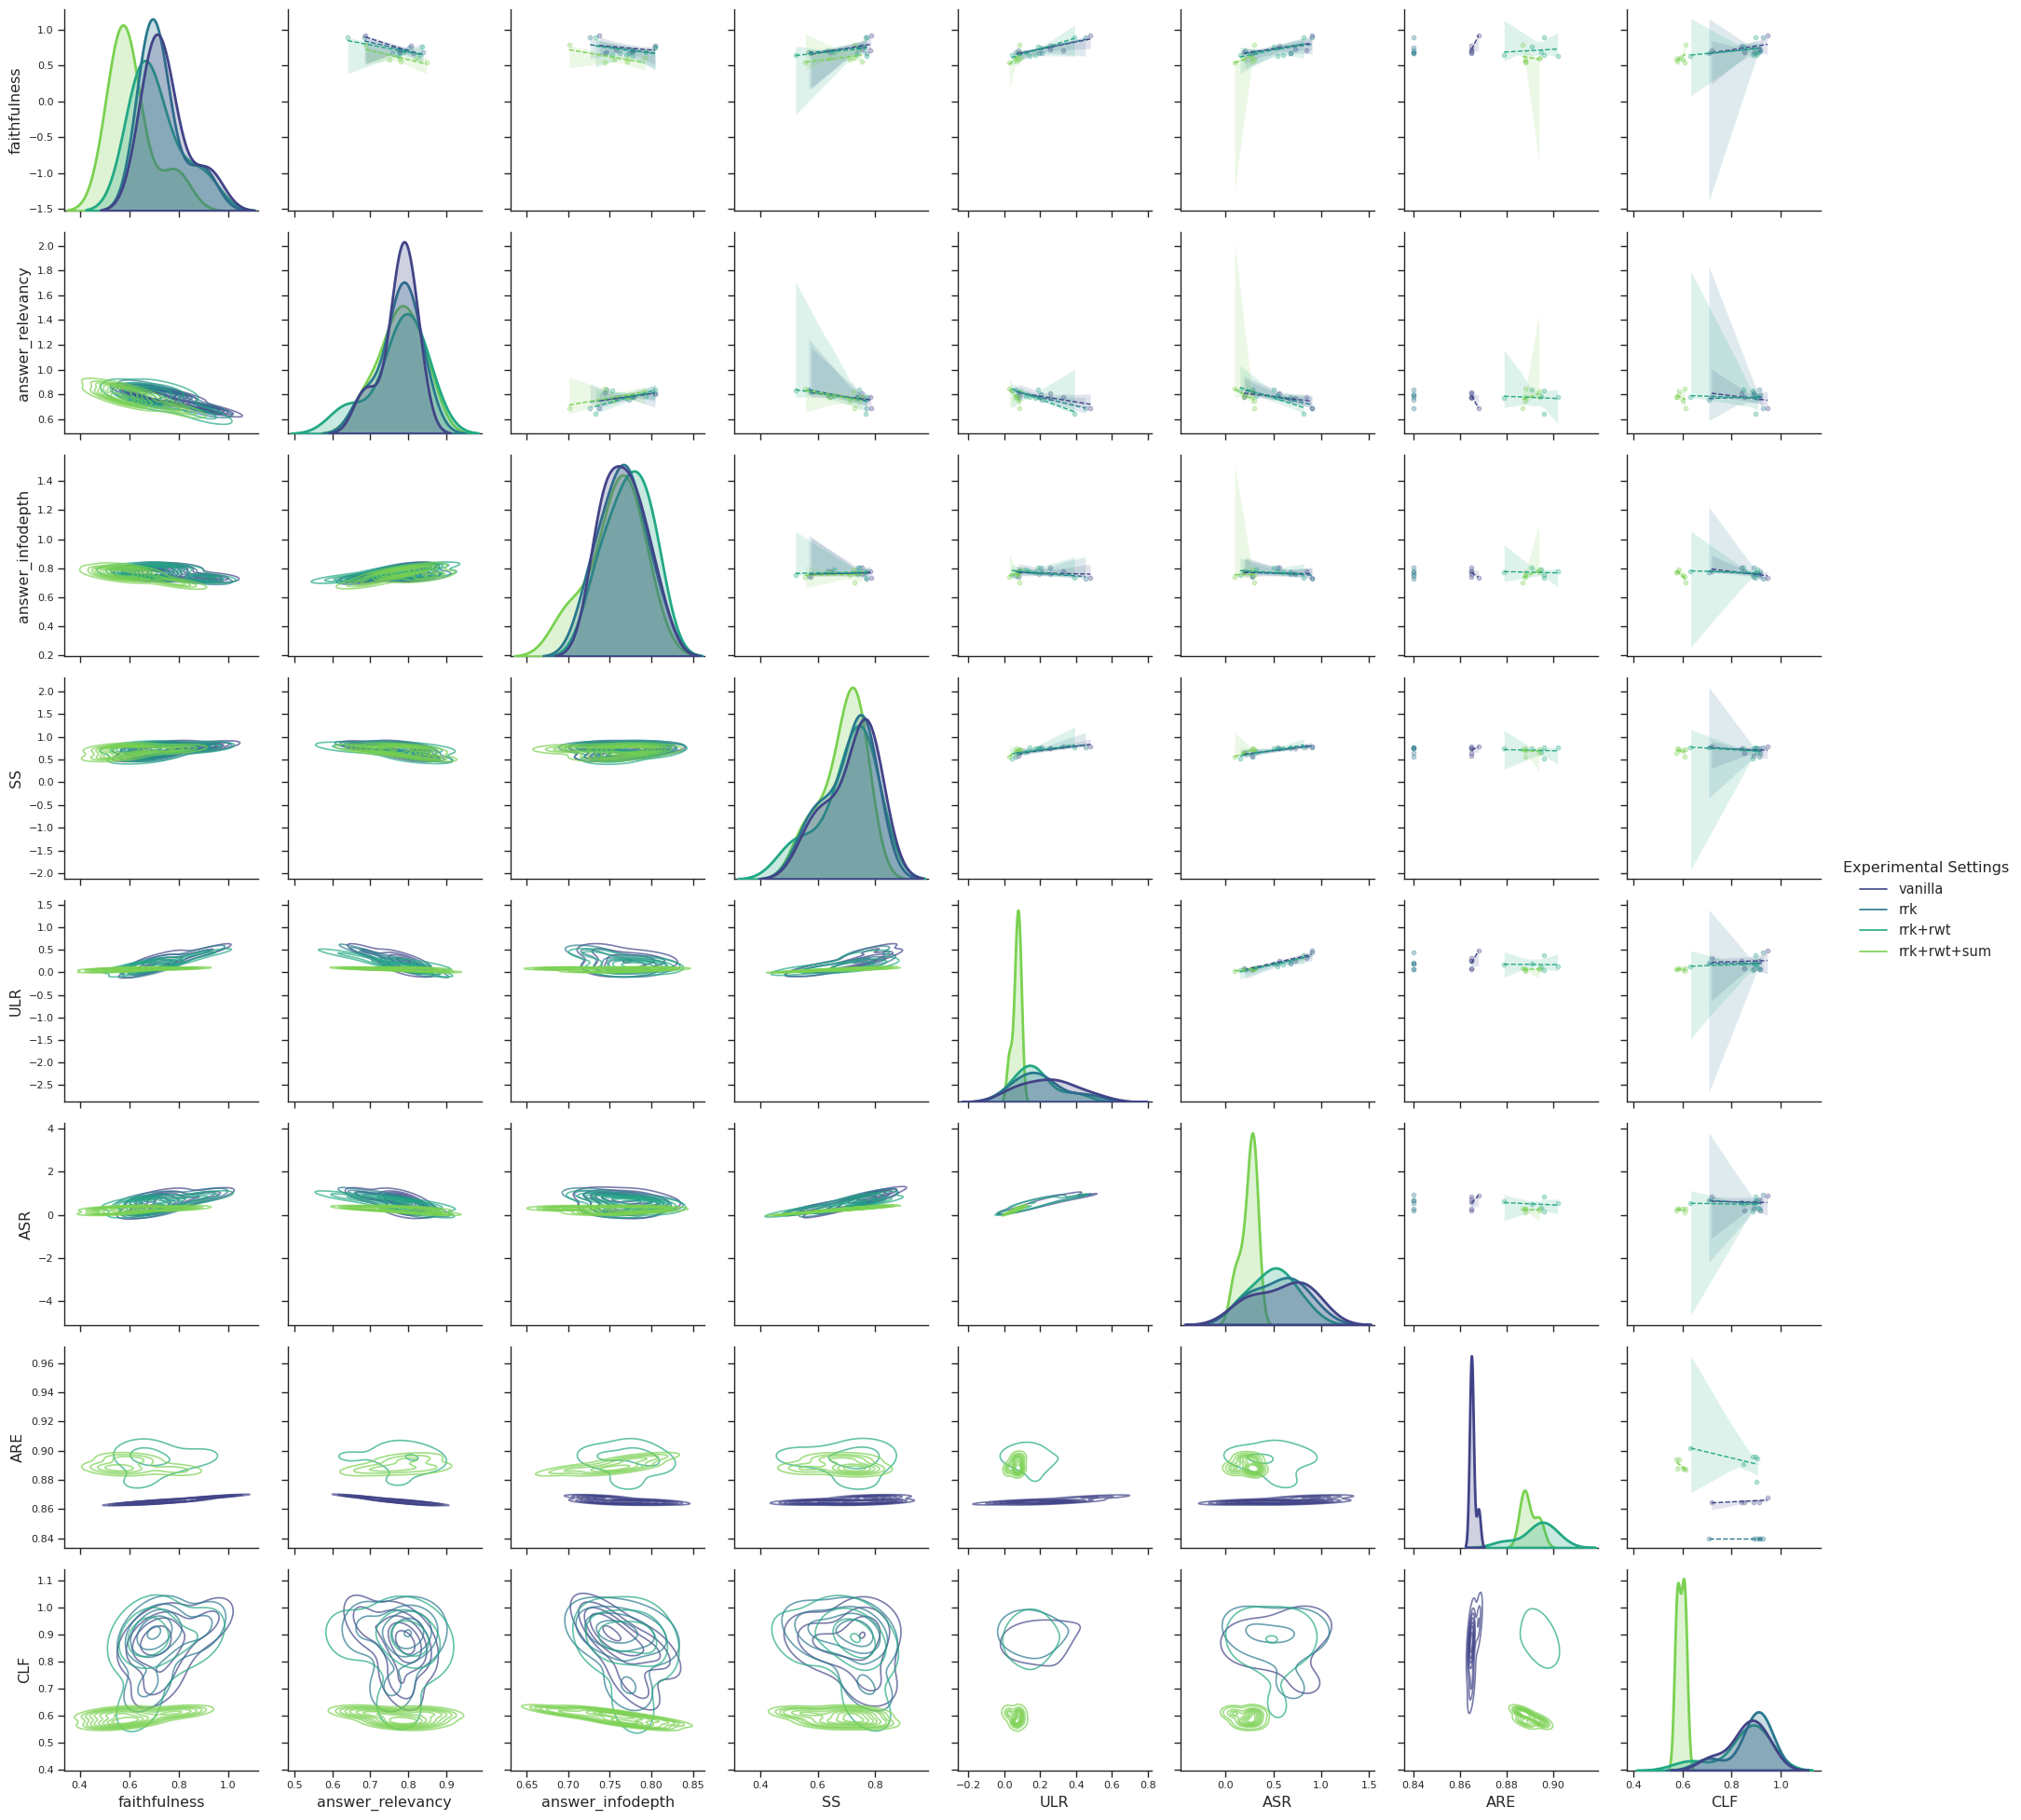

In [9]:
def plot_multi_metric_matrix(full_df):
    # 选择你想展示的因变量指标列
    metrics = ['faithfulness', 'answer_relevancy', 'answer_infodepth', 'SS', 'ULR', 'ASR', 'ARE', 'CLF']
    
    # 使用 seaborn 的 PairGrid
    g = sns.PairGrid(full_df, vars=metrics, hue='Setting', palette='viridis', diag_sharey=False)
    
    # 上三角：绘制散点图和回归线
    g.map_upper(sns.regplot, scatter_kws={'alpha':0.3, 's':10}, line_kws={'lw':1, 'ls':'--'})
    
    # 下三角：绘制密度图 (避免数据点太多导致混乱)
    g.map_lower(sns.kdeplot, alpha=0.7)
    
    # 对角线：绘制单指标分布
    g.map_diag(sns.kdeplot, lw=2, fill=True)
    
    # 美化
    g.add_legend(title="Experimental Settings")
    for ax in g.axes.flatten():
        ax.tick_params(labelsize=8)
    
    plt.show()
plot_multi_metric_matrix(df[df['Dataset']=='FiQA'])

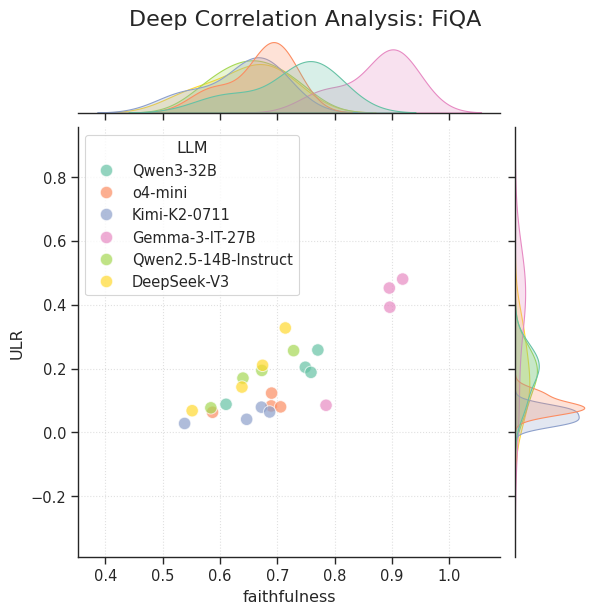

In [10]:
# 示例：针对某一个数据集进行深度分析
def plot_joint_analysis(dataset_df, ds_name):
    g = sns.jointplot(data=dataset_df, x='faithfulness', y='ULR', 
                      hue='LLM', kind='scatter', alpha=0.7, s=80,
                      palette='Set2', marginal_kws=dict(fill=True))
    
    g.fig.suptitle(f'Deep Correlation Analysis: {ds_name}', y=1.02, size=16)
    g.ax_joint.grid(True, linestyle=':', alpha=0.6)
    plt.show()

plot_joint_analysis(df[df['Dataset']=='FiQA'], 'FiQA')
# plot_joint_analysis(df[df['Dataset']=='NFcorpus'], 'NFcorpus')
# plot_joint_analysis(df[df['Dataset']=='SciFact'], 'SciFact')